## 1. Instalasi Library

In [ ]:
!pip install -q ultralytics opencv-python-headless pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.1 MB/s eta 0:00:00


## 2. Import Library

In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

os.makedirs('inputs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Load Model Pre-trained YOLOv8

Model `yolov8n.pt` (nano) dipilih karena ringan dan cepat untuk inferensi, sudah dilatih pada dataset **COCO** (80 kelas). Bisa diganti ke `yolov8s.pt` / `yolov8m.pt` untuk akurasi lebih tinggi dengan kompromi kecepatan.

In [ ]:
model = YOLO('yolov8n.pt')  # otomatis mengunduh bobot pre-trained saat pertama kali dijalankan
print(model.names)  # daftar 80 kelas COCO yang dikenali model

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

## 4. Unduh Citra Uji (Contoh Publik)

Menggunakan citra contoh yang disediakan publik oleh Ultralytics untuk pengujian (berisi objek umum seperti orang, bus, mobil, dsb — mirip distribusi kelas pada COCO).

In [ ]:
sample_urls = {
    'coco_2.jpg': 'http://images.cocodataset.org/val2017/000000000139.jpg',
    'coco_3.jpg': 'http://images.cocodataset.org/val2017/000000000632.jpg',
}

for fname, url in sample_urls.items():
    path = f'inputs/{fname}'
    if not os.path.exists(path):
        os.system(f'wget -q -O {path} {url}')
    print(fname, 'OK' if os.path.exists(path) else 'GAGAL')

# Catatan: silakan ganti/upload citra sendiri ke folder 'inputs/'
# lalu tambahkan nama filenya pada list image_paths di sel berikutnya.

coco_2.jpg OK
coco_3.jpg OK


## 5. Inferensi Deteksi Objek

In [ ]:
image_paths = [f'inputs/{f}' for f in sample_urls.keys()]

CONF_THRESHOLD = 0.25  # ambang batas confidence score

results_list = model.predict(source=image_paths, conf=CONF_THRESHOLD, save=False, verbose=False)
print(f'Jumlah citra diproses: {len(results_list)}')

# Catat waktu inferensi (ms) tiap citra, tersedia otomatis dari Ultralytics (result.speed)
timing_rows = []
for result in results_list:
    timing_rows.append({
        'citra': os.path.basename(result.path),
        'preprocess_ms': round(result.speed['preprocess'], 2),
        'inference_ms': round(result.speed['inference'], 2),
        'postprocess_ms': round(result.speed['postprocess'], 2),
    })
df_timing = pd.DataFrame(timing_rows)
df_timing['total_ms'] = df_timing[['preprocess_ms','inference_ms','postprocess_ms']].sum(axis=1)
df_timing.to_csv('outputs/waktu_inferensi.csv', index=False)
df_timing

Jumlah citra diproses: 2


,citra,preprocess_ms,inference_ms,postprocess_ms,total_ms
0,image0.jpg,10.73,43.36,20.65,74.74
1,image1.jpg,10.73,43.36,20.65,74.74


## 6. Visualisasi Bounding Box, Label Kelas, dan Confidence Score

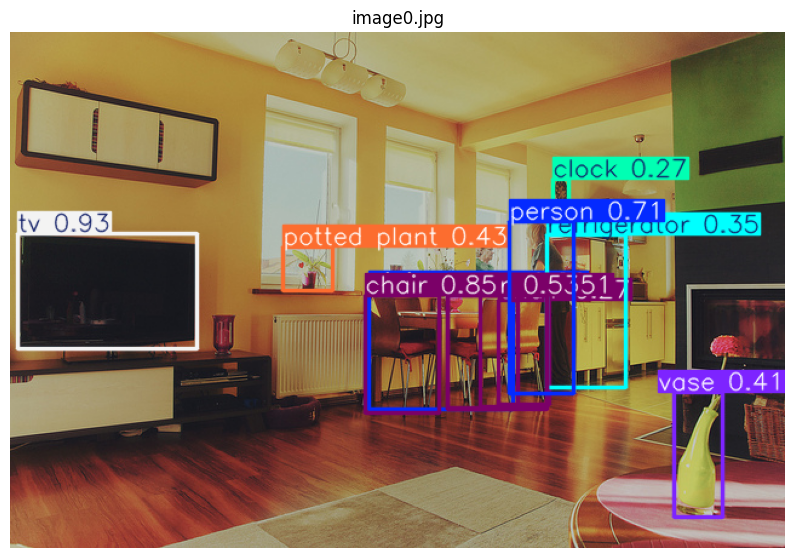

Disimpan: outputs/detected_image0.jpg


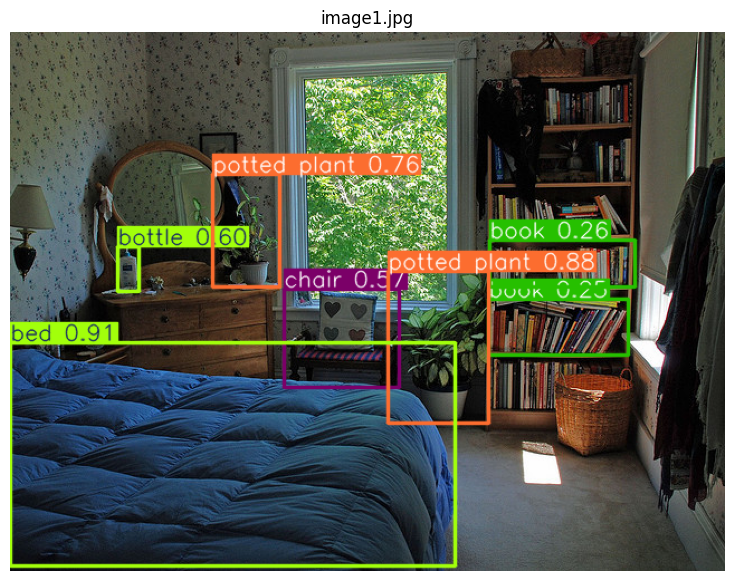

Disimpan: outputs/detected_image1.jpg


In [ ]:
for i, result in enumerate(results_list):
    annotated = result.plot()  # gambar dengan bounding box + label + confidence otomatis
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    out_path = f'outputs/detected_{os.path.basename(result.path)}'
    cv2.imwrite(out_path, annotated)

    plt.figure(figsize=(10, 7))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title(os.path.basename(result.path))
    plt.show()

    print(f'Disimpan: {out_path}')

## 7. Daftar Objek Terdeteksi (Tabel)

Menampilkan daftar objek terdeteksi per citra: kelas, confidence score, dan koordinat bounding box (x_min, y_min, x_max, y_max).

In [ ]:
rows = []
for result in results_list:
    img_name = os.path.basename(result.path)
    for box in result.boxes:
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf = float(box.conf[0])
        x1, y1, x2, y2 = [round(float(v), 1) for v in box.xyxy[0]]
        rows.append({
            'citra': img_name,
            'kelas': cls_name,
            'confidence': round(conf, 3),
            'x_min': x1, 'y_min': y1, 'x_max': x2, 'y_max': y2
        })

df_detections = pd.DataFrame(rows)
df_detections.to_csv('outputs/daftar_objek_terdeteksi.csv', index=False)
df_detections

,citra,kelas,confidence,x_min,y_min,x_max,y_max
0,image0.jpg,tv,0.927,6.2,166.2,154.5,261.9
1,image0.jpg,chair,0.853,293.2,217.5,354.4,314.9
2,image0.jpg,person,0.712,412.6,157.0,465.7,298.9
3,image0.jpg,chair,0.530,361.7,217.0,443.8,311.2
4,image0.jpg,chair,0.508,361.2,217.6,419.0,310.8
5,image0.jpg,chair,0.507,388.4,217.8,443.9,309.7
6,image0.jpg,potted plant,0.425,225.9,177.4,266.6,213.1
7,image0.jpg,vase,0.414,548.9,298.0,588.0,400.9
8,image0.jpg,refrigerator,0.354,443.7,167.5,508.6,293.0
9,image0.jpg,clock,0.274,448.6,121.2,461.4,141.4


## 8. Ringkasan Jumlah Objek per Kelas

In [ ]:
summary = df_detections.groupby(['citra', 'kelas']).size().reset_index(name='jumlah')
summary_pivot = summary.pivot(index='kelas', columns='citra', values='jumlah').fillna(0).astype(int)
summary_pivot

citra,image0.jpg,image1.jpg
kelas,,
bed,0,1
book,0,2
bottle,0,1
chair,5,1
clock,1,0
dining table,1,0
person,1,0
potted plant,1,2
refrigerator,1,0


## 9. Visualisasi Tambahan: Distribusi Objek per Kelas

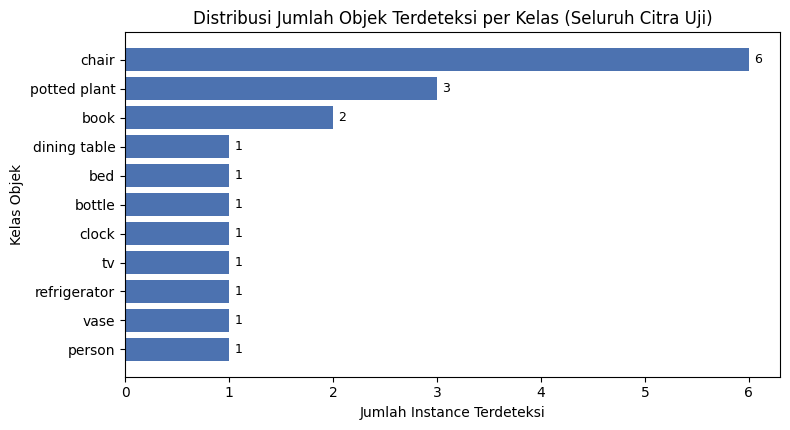

In [ ]:
class_counts = df_detections['kelas'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, max(4, 0.4*len(class_counts))))
plt.barh(class_counts.index, class_counts.values, color='#4C72B0')
plt.xlabel('Jumlah Instance Terdeteksi')
plt.ylabel('Kelas Objek')
plt.title('Distribusi Jumlah Objek Terdeteksi per Kelas (Seluruh Citra Uji)')
for i, v in enumerate(class_counts.values):
    plt.text(v + 0.05, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/distribusi_kelas.png', dpi=150)
plt.show()

## 10. Visualisasi Tambahan: Distribusi Confidence Score

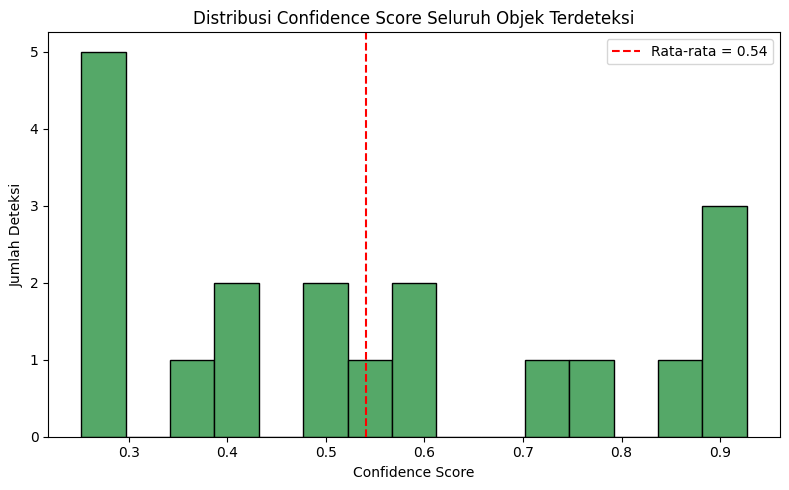

count    19.000000
mean      0.540737
std       0.240389
min       0.252000
25%       0.314000
50%       0.508000
75%       0.738500
max       0.927000
Name: confidence, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_detections['confidence'], bins=15, color='#55A868', edgecolor='black')
plt.axvline(df_detections['confidence'].mean(), color='red', linestyle='--',
            label=f"Rata-rata = {df_detections['confidence'].mean():.2f}")
plt.xlabel('Confidence Score')
plt.ylabel('Jumlah Deteksi')
plt.title('Distribusi Confidence Score Seluruh Objek Terdeteksi')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/distribusi_confidence.png', dpi=150)
plt.show()

print(df_detections['confidence'].describe())

## 11. Analisis Sensitivitas Ambang Batas (Confidence Threshold)

Karena tidak menggunakan data ground truth (model pre-trained, bukan hasil pelatihan sendiri), evaluasi kuantitatif dilakukan dengan menganalisis pengaruh ambang batas *confidence* terhadap jumlah objek yang berhasil terdeteksi pada seluruh citra uji.

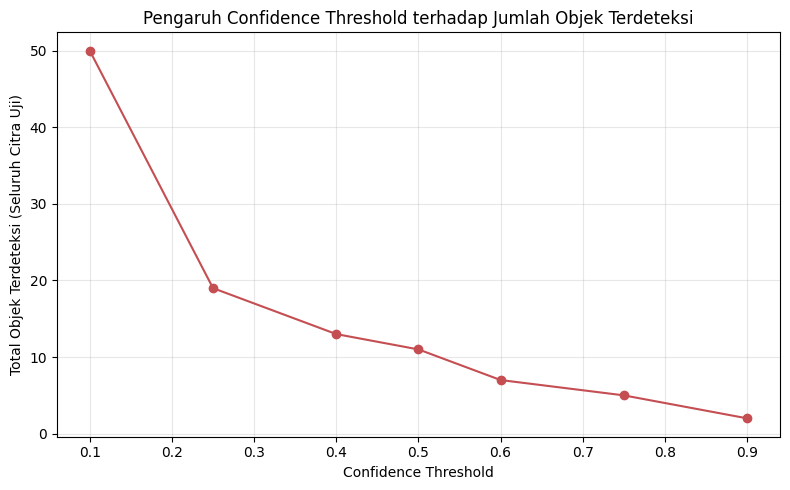

,confidence_threshold,total_objek_terdeteksi
0,0.10,50
1,0.25,19
2,0.40,13
3,0.50,11
4,0.60,7
5,0.75,5
6,0.90,2


In [ ]:
thresholds = [0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9]
sensitivity_rows = []

for th in thresholds:
    res = model.predict(source=image_paths, conf=th, verbose=False)
    total_objects = sum(len(r.boxes) for r in res)
    sensitivity_rows.append({'confidence_threshold': th, 'total_objek_terdeteksi': total_objects})

df_sensitivity = pd.DataFrame(sensitivity_rows)
df_sensitivity.to_csv('outputs/sensitivitas_threshold.csv', index=False)

plt.figure(figsize=(8, 5))
plt.plot(df_sensitivity['confidence_threshold'], df_sensitivity['total_objek_terdeteksi'],
          marker='o', color='#C44E52')
plt.xlabel('Confidence Threshold')
plt.ylabel('Total Objek Terdeteksi (Seluruh Citra Uji)')
plt.title('Pengaruh Confidence Threshold terhadap Jumlah Objek Terdeteksi')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/sensitivitas_threshold.png', dpi=150)
plt.show()

df_sensitivity

## 12. Unduh Hasil (opsional, di Colab)

In [ ]:
# Jalankan sel ini di Google Colab untuk mengunduh hasil sebagai zip
import shutil
shutil.make_archive('hasil_deteksi_objek', 'zip', 'outputs')

try:
    from google.colab import files
    files.download('hasil_deteksi_objek.zip')
except ImportError:
    print('Bukan lingkungan Colab — file tersedia di hasil_deteksi_objek.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>